In [56]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [57]:
data = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_2332\277842057.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")


In [58]:
data.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [59]:
data.shape

(11055, 32)

In [60]:
data["Result"].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           11055 non-null  int64
 1   having_IP_Address            11055 non-null  int64
 2   URL_Length                   11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [64]:
X = data.drop(["id","Result"], axis=1)
y = data["Result"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
model = RandomForestClassifier(n_estimators=100, class_weight="balanced", max_depth=20, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, random_state=42)

In [68]:
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 96.92%
              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       956
           1       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [69]:
# Save the model to disk
joblib.dump(model, 'safe_surfer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved successfully as safe_surfer_model.pkl")

Model saved successfully as safe_surfer_model.pkl


In [70]:
import joblib

loaded_model = joblib.load('safe_surfer_model.pkl')

result = loaded_model.predict([[1]*30]) 
print(f"Test Prediction: {result}")

Test Prediction: [1]


--- Model Accuracy: 96.92% ---

Classification Report:
               precision    recall  f1-score   support

          -1       0.97      0.96      0.96       956
           1       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_2332\3201099969.py:8: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")


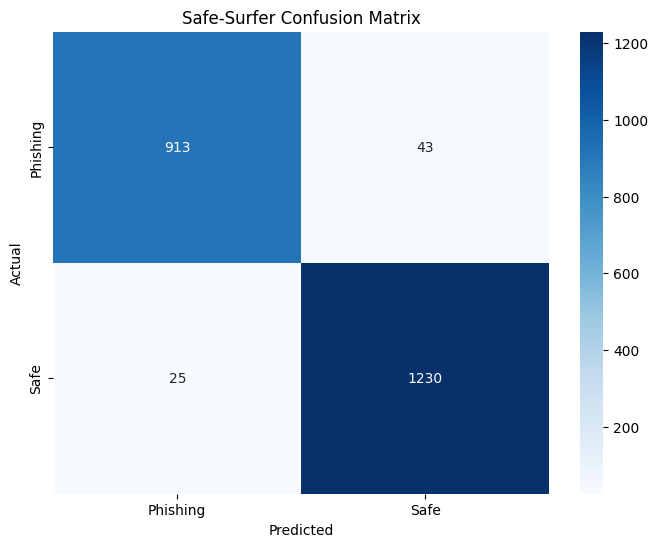

In [71]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = joblib.load('safe_surfer_model.pkl')
df = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")

X = df.drop(['id', 'Result'], axis=1)
y = df['Result']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test_scaled = scaler.fit_transform(X_test)
y_pred = model.predict(X_test_scaled)

print(f"--- Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}% ---")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Safe'], yticklabels=['Phishing', 'Safe'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Safe-Surfer Confusion Matrix')
plt.show()

In [72]:
sample_url_features = X_test.iloc[10].values.reshape(1, -1)
actual_label = y_test.iloc[10]

prediction = model.predict(sample_url_features)

status = "LEGITIMATE (Safe)" if prediction[0] == 1 else "PHISHING (Danger!)"
actual_status = "Safe" if actual_label == 1 else "Phishing"

print(f"Prediction for sample: {status}")
print(f"Actual Label was: {actual_status}")

Prediction for sample: LEGITIMATE (Safe)
Actual Label was: Safe
